## **Import libraries**

In [ ]:
import os
import random

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd

from natsort import natsorted
from collections import defaultdict

import torch
import torch.nn as nn
from transformers import set_seed as transformers_set_seed

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    DOCXToJSONSConfig,
    LLMConfig
)
from SARVI.models.losses import (
    MoMLoss
)

from SARVI.data_io.reader import (
    textwrap,
    read_txt_list, read_ann_list,
    read_json_single,
    read_excel_single
)
from SARVI.data_io.writing import (
    write_torch_checkpoint, write_json_extra_docs, write_parquet
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    tokenizer_ner, model_ner, initialize_bio_ner_model
)
from SARVI.services.common.icd_pred_funcs import(
    initialize_icd10_hs_head_model,
    initialize_icd10_hs_prediction_model,
    initialize_icd10_no_hs_head_model,
)
from SARVI.services.sync_funcs.ner_funcs import (
    prepare_data as prepare_data_SYNC,
    construct_loaders_ner as construct_loaders_ner_SYNC,
    run_bio_nerclassifier as run_bio_nerclassifier_SYNC
)

from SARVI.services.async_funcs.llm_funcs import (
    asyncio
)

Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[2026-05-27 17:07:03] INFO SentenceTransformer.py:219: Use pytorch device_name: cuda:0
[2026-05-27 17:07:03] INFO SentenceTransformer.py:227: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: PipelineContext):
    print("0. Initializing variables\n")
    # create_intermediate_folder_name(ctx)

    #################################################################################################################

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())
    
    if ctx.ussage == "generative":
        llm = load_llm(ctx.llm_config)
        prompt = textwrap.dedent(prompts_total["report_to_data"])
        modelo_ner = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        icd10_thresholds = None
    else:
        llm = None
        prompt = None
        modelo_ner = [None, None]
        node_list = load_tree_hierarchical_module(df_reference)

        root = node_list["root"]
        root.set_indexes()
        label2id_hs = {key.name: value for key, value in root.node_to_id.items()}
        id2label_hs = {value: key for key, value in label2id_hs.items()}
        label2id_no_hs = {id2label_hs[value.item()]: i for i, value in enumerate(root.leaf_indexes)}
        id2label_no_hs = {value: key for key, value in label2id_no_hs.items()}
        label2id_ICD10 = [label2id_hs, label2id_no_hs]
        id2label_ICD10 = [id2label_hs, id2label_no_hs]
        id_no_hs_to_id_hs = {id_no_hs: label2id_hs[label_name] for label_name, id_no_hs in label2id_no_hs.items()}

        # modelo_icd10_head = [initialize_icd10_hs_head_model(ctx, "ICD10_HS_checkpoint.pt", root), initialize_icd10_no_hs_head_model(ctx, "ICD10_NO_HS_checkpoint.pt", label2id_no_hs, root)]
        # modelo_icd10_prediction = [initialize_icd10_hs_prediction_model(ctx, "ICD10_HS_checkpoint.pt", label2id_hs, root), None]
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")
    
    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        icd10_thresholds=icd10_thresholds
    )

    return config

In [3]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="deterministic",
    folder_and_archive_name="E3C/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)

0. Initializing variables



Hierarchical tree construction: Cleaning data:   0%|          | 0/102426 [00:00<?, ?code/s]

## **Run BIO NER data creation**

### **Create data**

In [4]:
print("1.1. Creating NER data // Train data")
dict_data_train = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_train = pd.DataFrame(list(dict_data_train.items()), columns=["archivo_origen", "Text"])

dict_ann_train = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_train = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_train.items()])
# df_ann = None

data_prepared_train, all_window_labels_train, file_names_train = prepare_data_SYNC(df_data_train, data_ann=df_ann_train, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

print("1.1. Creating NER data // Dev data")
dict_data_dev = read_txt_list(ctx.paths.data_input / "E3C/dev")
df_data_dev = pd.DataFrame(list(dict_data_dev.items()), columns=["archivo_origen", "Text"])

dict_ann_dev = read_ann_list(ctx.paths.data_input / "E3C/dev")
df_ann_dev = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_dev.items()])
# df_ann = None

data_prepared_dev, all_window_labels_dev, file_names_dev = prepare_data_SYNC(df_data_dev, data_ann=df_ann_dev, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

1.1. Creating NER data // Train data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/48 [00:00<?, ?tex…

Token indices sequence length is longer than the specified maximum sequence length for this model (936 > 512). Running this sequence through the model will result in indexing errors


1.1. Creating NER data // Dev data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/16 [00:00<?, ?tex…

> Example of label output

In [5]:
### Example of labels
example_window_labels = all_window_labels_train[2][0]
example_data_prepared = data_prepared_train[2][0]["input_ids"]

for i,(label,token) in enumerate(zip(example_window_labels,tokenizer_ner.convert_ids_to_tokens(example_data_prepared))):
    if label != "O":
        print(f"{label}: {token}")
        if i+1 <= len(example_window_labels) and example_window_labels[i+1] == "O":
            print()

1_B-LIVB: ▁Mu
1_B-LIVB: jer
1_I-LIVB: ▁de
1_I-LIVB: ▁28
1_I-LIVB: ▁años

2_B-DISO: ▁e
2_B-DISO: piga
2_B-DISO: stra
2_B-DISO: lgi
2_B-DISO: as

3_B-DISO: ▁síndrome
3_I-DISO: ▁constitucional

4_B-Date: ▁un
4_I-Date: ▁mes

5_B-DISO: ▁masa

6_B-DISO: ▁met
6_B-DISO: ást
6_B-DISO: asis
6_I-DISO: ▁hep
6_I-DISO: ática
6_I-DISO: s

7_B-DISO: ▁tumor

8_B-DISO: ▁G
8_B-DISO: ANT

9_B-Date: ▁diario
9_B-Date: s

10_B-Date: ▁los
10_I-Date: ▁seis
10_I-Date: ▁meses

11_B-DISO: ▁met
11_B-DISO: ást
11_B-DISO: asis
11_I-DISO: ▁hep
11_I-DISO: ática
11_I-DISO: s

12_B-Date: ▁al
12_I-Date: ▁año

13_B-Date: ▁tres
13_I-Date: ▁años

14_B-DISO: ▁reci
14_B-DISO: di
14_B-DISO: va
14_I-DISO: ▁local



> Total count of labels

In [6]:
labels_unique = defaultdict(int)
for i in [i for window in all_window_labels_train for sublist in window for i in sublist]:
    labels_unique[i] += 1


bio_order = {"B": 0, "I": 1, "O": 2}
ordered_data = defaultdict(labels_unique.default_factory, sorted(labels_unique.items(), key=lambda x:(x[0].split("-", 1)[1] if "-" in x[0] else x[0], bio_order.get(x[0].split("-", 1)[0], 99))))
ordered_data

defaultdict(int,
            {'2_B-DISO': 78,
             '2_I-DISO': 45,
             '3_B-DISO': 69,
             '4_B-DISO': 88,
             '5_B-DISO': 86,
             '5_I-DISO': 60,
             '7_B-DISO': 79,
             '7_I-DISO': 57,
             '10_B-DISO': 98,
             '10_I-DISO': 65,
             '11_B-DISO': 96,
             '12_B-DISO': 93,
             '13_B-DISO': 123,
             '13_I-DISO': 84,
             '14_B-DISO': 150,
             '15_B-DISO': 122,
             '15_I-DISO': 133,
             '16_B-DISO': 115,
             '17_B-DISO': 146,
             '18_B-DISO': 127,
             '19_B-DISO': 119,
             '20_B-DISO': 104,
             '21_B-DISO': 120,
             '22_B-DISO': 112,
             '24_B-DISO': 100,
             '25_B-DISO': 102,
             '26_B-DISO': 54,
             '26_I-DISO': 53,
             '27_B-DISO': 75,
             '28_B-DISO': 53,
             '28_I-DISO': 56,
             '29_B-DISO': 76,
             '29_I

### **Create DataLoaders and models**

In [7]:
class TokenCrossEntropyLoss(nn.Module):
    def __init__(self, weight=None, ignore_index=-100, reduction="mean"):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(
            weight=weight,
            ignore_index=ignore_index,
            reduction="none"
        )
        self.reduction = reduction
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        """
        logits:  (B, T, C)
        targets: (B, T)
        """
        B, T, C = logits.shape

        flat_logits = logits.reshape(-1, C)
        flat_targets = targets.reshape(-1)

        loss = self.ce(flat_logits, flat_targets)
        loss = loss.view(B, T)

        if self.reduction == "none":
            return loss

        valid_mask = targets != self.ignore_index
        loss = loss * valid_mask

        if self.reduction == "sum":
            return loss.sum()

        return loss.sum() / valid_mask.sum().clamp(min=1)

In [ ]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loaders_ner_SYNC(data_prepared_train, all_window_labels_train, file_names_train, ner_type="bio", seed=SEED, ignore_o_labels=True, batch_size=4)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loaders_ner_SYNC(data_prepared_dev, all_window_labels_dev, file_names_dev, ner_type="bio", label2id=label2id, id2label=id2label, seed=SEED, ignore_o_labels=True, batch_size=4)

source_label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/CodiEsp/label2id_bio_nerclassifier.json")
config.modelo_ner[1] = initialize_bio_ner_model(ctx, model_ner, len(id2label), "NERTraining/BIO/CodiEsp/bio_nerclassifier_checkpoint.pt", source_label2id=source_label2id, target_label2id=label2id)

ignore_index = -100
class_counts = torch.zeros(len(label2id))
for batch in data_loader_full_train:
    labels = batch["window_labels"].view(-1)
    valid_labels = labels[labels != ignore_index]
    class_counts += torch.bincount(valid_labels, minlength=len(label2id)).float()
class_counts = class_counts.to(ctx.device)
present = class_counts > 0
weights = torch.zeros_like(class_counts, device=ctx.device)
weights[present] = 1.0 / class_counts[present]
weights[present] = weights[present] / weights[present].sum() * present.sum()

optimizer = torch.optim.AdamW(config.modelo_ner[1].parameters(), lr=1e-5, weight_decay=0.001)
# criterion = MoMLoss(M=512, majority_label=label2id["O"], delta=0.05,
#                     # sentence_loss_fn=DiceLoss(epsilon=1.0, delta=0.01), 
#                     sentence_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
#                     majority_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
#                     ignore_index=ignore_index)
criterion = TokenCrossEntropyLoss(reduction="mean", weight=weights, ignore_index=ignore_index)

### **Train model**

In [9]:
seed_everything(SEED)

print("1.2. Running NER model // BIO")
results = run_bio_nerclassifier_SYNC(config.modelo_ner[1], data_loader=data_loader_full_train, device=ctx.device, id2label=id2label, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=50, patience=5, ignore_index=ignore_index)

write_torch_checkpoint(ctx=ctx, name="NERTraining/BIO/E3C/bio_nerclassifier_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="NERTraining/BIO/E3C/bio_nerclassifier_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k != "best_model_state"}]))
write_json_extra_docs(ctx=ctx, file_name="NERTraining/BIO/E3C/id2label_bio_nerclassifier", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="NERTraining/BIO/E3C/label2id_bio_nerclassifier", content=label2id)

1.2. Running NER model // BIO


BIO NER / Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

BIO NER / Training epoch 1 / Train set:   0%|          | 0/12 [00:00<?, ?batch/s]

BIO NER / Training epoch 1 / Dev set:   0%|          | 0/4 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.6514    0.6911    0.6707      1049
        Date     0.1172    0.1986    0.1474       141
        LIVB     0.2230    0.2973    0.2548       111

   micro avg     0.5240    0.6042    0.5612      1301
   macro avg     0.3305    0.3957    0.3576      1301
weighted avg     0.5569    0.6042    0.5785      1301

Epoch 1/50 | train loss: 0.995581 | dev loss: 0.670160 | Best F1 (macro): 0.3576


...

BIO NER / Training epoch 14 / Dev set:   0%|          | 0/4 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.8074    0.7712    0.7889      1049
        Date     0.3722    0.4752    0.4174       141
        LIVB     0.4468    0.5676    0.5000       111

   micro avg     0.7098    0.7218    0.7157      1301
   macro avg     0.5421    0.6047    0.5688      1301
weighted avg     0.7295    0.7218    0.7240      1301

Epoch 14/50 | train loss: 0.139690 | dev loss: 0.329367 | Best F1 (macro): 0.5743


BIO NER / Training epoch 15 / Train set:   0%|          | 0/12 [00:00<?, ?batch/s]

BIO NER / Training epoch 15 / Dev set:   0%|          | 0/4 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.8099    0.7798    0.7946      1049
        Date     0.3584    0.4397    0.3949       141
        LIVB     0.5000    0.4955    0.4977       111

   micro avg     0.7231    0.7187    0.7209      1301
   macro avg     0.5561    0.5717    0.5624      1301
weighted avg     0.7345    0.7187    0.7259      1301


Early stopping at epoch 15 | Best epoch: 10 | Best dev macro F1: 0.574294


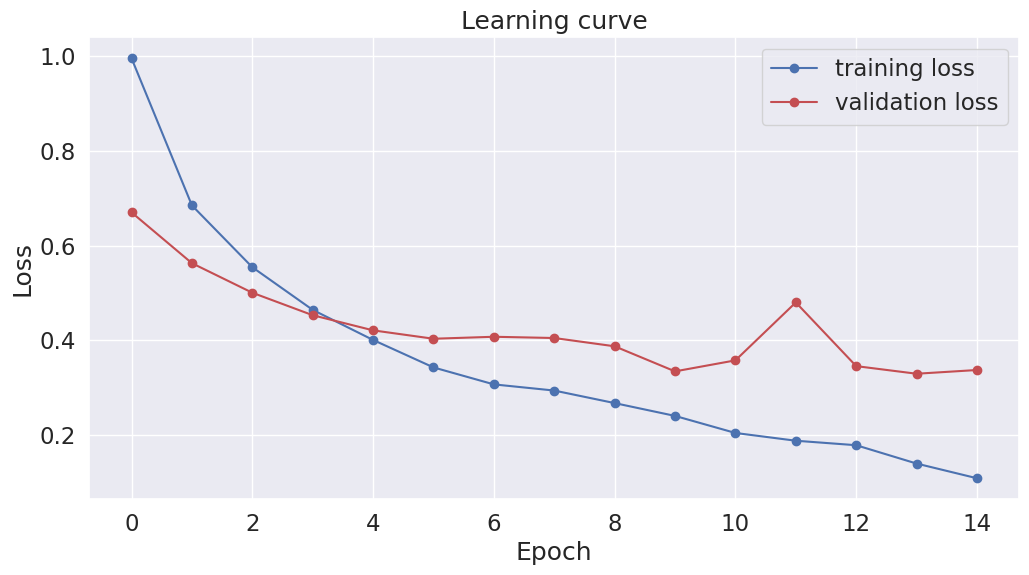

In [10]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### **Eval model**

In [11]:
print("1.1. Creating NER data // Test data")
# dict_data_test = read_txt_list(ctx.paths.data_input / "E3C/test")
dict_data_test = read_txt_list(ctx.paths.data_input / "E3C/test")
df_data_test = pd.DataFrame(list(dict_data_test.items()), columns=["archivo_origen", "Text"])

# dict_ann_test = read_ann_list(ctx.paths.data_input / "E3C/test")
dict_ann_test = read_ann_list(ctx.paths.data_input / "E3C/test")
df_ann_test = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test.items()])
# df_ann = None

data_prepared_test, all_window_labels_test, file_names_test = prepare_data_SYNC(df_data_test, data_ann=df_ann_test, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

1.1. Creating NER data // Test data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/17 [00:00<?, ?tex…

In [12]:
id2label = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/E3C/id2label_bio_nerclassifier.json")
label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/E3C/label2id_bio_nerclassifier.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}
dataset_full_test, data_loader_full_test, _, _ = construct_loaders_ner_SYNC(data_prepared_test, all_window_labels_test, file_names_test, ner_type="bio", label2id=label2id, id2label=id2label, seed=SEED)

config.modelo_ner[1] = initialize_bio_ner_model(ctx, model_ner, len(id2label), "NERTraining/BIO/E3C/bio_nerclassifier_checkpoint.pt")

In [13]:
results = run_bio_nerclassifier_SYNC(config.modelo_ner[1], data_loader=data_loader_full_test, device=ctx.device, id2label=id2label, train=False)

BIO NER / Inference:   0%|          | 0/3 [00:00<?, ?batch/s]


Classification report:
              precision    recall  f1-score   support

        DISO     0.2263    0.6320    0.3332       750
        Date     0.0056    0.0989    0.0106        91
        LIVB     0.0596    0.2212    0.0939       104

   micro avg     0.1239    0.5354    0.2013       945
   macro avg     0.0972    0.3174    0.1459       945
weighted avg     0.1867    0.5354    0.2758       945



## **Results to .ann format**

In [14]:
from SARVI.services.common.utils.ann_utils import ner_outputs_to_ann
from SARVI.data_io.writing import write_ann_list

In [15]:
ann_format = ner_outputs_to_ann(results, id2label, data_loader=data_loader_full_test, original_texts=df_data_test, tokenizer=tokenizer_ner)
# write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / ctx.folder_and_archive_name / "bio")
write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / "E3C/test" / "bio")

## **NER results**

In [16]:
from SARVI.services.common.ner_funcs import classification_report_ner

In [17]:
# dict_ann_test_true = read_ann_list(ctx.paths.data_input / "E3C/test")
dict_ann_test_true = read_ann_list(ctx.paths.data_input / "E3C/test")
df_ann_test_true = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_true.items()])

# dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / ctx.folder_and_archive_name / "bio")
dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / "E3C/test" / "bio")
df_ann_test_pred = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_pred.items()])

label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/label2id_span_nerclassifier.json")

In [18]:
results = classification_report_ner(df_ann_test_true, df_ann_test_pred, [k for k in label2id.keys() if k != "O"])

              precision    recall  f1-score   support   type_1   type_2   type_3   type_4   type_5

        LIVB     0.0191    0.0806    0.0309        62      199        0        0        0       57
        Date     0.0075    0.1132    0.0140        53      747        0        0        0       47
    Spec_cue     0.0000    0.0000    0.0000         0        0        0        0        0        0
     Neg_cue     0.0000    0.0000    0.0000         0        0        0        0        0        0
        DISO     0.0378    0.1195    0.0575       251      546        0        4        0      217

   micro avg     0.0221    0.1120    0.0369       366     1492        0        4        0      321
   macro avg     0.0129    0.0627    0.0205       366     1492        0        4        0      321
weighted avg     0.0303    0.1120    0.0467       366     1492        0        4        0      321
